# CIFAR-10 Image Classification: Comparing Deep Learning Architectures in PyTorch

## Project Overview

Five neural network architectures were implemented and compared, ranging from fully connected networks to convolutional neural networks with regularization techniques.

## Dataset

The CIFAR-10 dataset contains 60,000 RGB images across 10 object categories:

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

## Objective

Evaluate how network architecture, depth, convolutional layers, and regularization techniques affect classification performance.

In [78]:
import math

import matplotlib.pyplot as plt              
import seaborn as sns                        
import torch                                 
import torch.nn as nn                        
import torch.nn.functional as F              
import torch.optim as optim                  
import torchvision.datasets as datasets      
import torchvision.transforms as transforms  

sns.set()
torch.manual_seed(0)

import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [79]:
INPUT_SIZE    = 3 * 32 * 32   # CIFAR-10 image dimensions (32×32 RGB images)
NUM_CLASSES   = 10            # Number of target classes
BATCH_SIZE    = 100           # Training batch size
SAMPLE_DATA   = False         # Optional dataset reduction for faster experimentation
                            

In [80]:
transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
valset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

if SAMPLE_DATA: 
    trainset, _ = torch.utils.data.random_split(trainset, [BATCH_SIZE * 10, len(trainset) - BATCH_SIZE * 10])
    valset, _ = torch.utils.data.random_split(valset, [BATCH_SIZE * 10, len(valset) - BATCH_SIZE * 10])


train_loader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(valset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [82]:
def train(net, train_loader, val_loader,
          num_epochs, learning_rate,
          compute_accs=False):
    """
    This function trains the given network on the training data for the given number of epochs.
    If compute_accs is true, evaluates the train and val accuracy of the network at the end of
    each epoch.

    Args:
        net: The neural network to train
        train_loader, val_loader: The pytorch dataset loaders for the trainset and valset
        num_epochs: The number of times to loop over the batches in train_loader
        learning_rate: The learning rate for the optimizer
        compute_accs: A bool flag for whether or not this function should compute the train and val
                      accuracies at the end of each epoch. This feature is useful for visualizing
                      how the model is learning, but slows down training time.
    Returns:
        The train and val accuracies if compute_accs is True, None otherwise
    """
    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)

    train_accs = []
    val_accs = []
    best_val_acc = 0

    for epoch in range(1, num_epochs + 1):
        batch_num = 1
        for images, labels in train_loader:   # Loop over each batch in train_loader

            images = images.to(device)
            labels = labels.to(device)


            optimizer.zero_grad()               # Reset gradient for next computation
            outputs = net(images)               # Forward pass: compute the output class given a image
            loss = criterion(outputs, labels)   # Compute loss: difference between the pred and true
            loss.backward()                     # Backward pass: compute the weight
            optimizer.step()                    # Optimizer: update the weights of hidden nodes

            if batch_num % 100 == 0:  # Print every 100 batches
                print(f'Epoch [{epoch}/{num_epochs}], Step [{batch_num}/{len(train_loader)}], '
                      f'Loss: {loss.item():.4f}')

            batch_num += 1

        if compute_accs:
            train_acc = accuracy(net, train_loader)
            val_acc = accuracy(net, val_loader)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            best_val_acc = max(best_val_acc, val_acc)
            print(f'Epoch [{epoch}/{num_epochs}], Train Accuracy {100 * train_acc:.2f}%, Validation Accuracy {100 * val_acc:.2f}%')
            print(f'Best Validation Accuracy {100 * best_val_acc:.2f}%')

    if compute_accs:
        return train_accs, val_accs, best_val_acc


def accuracy(net, data_loader):
    """
    For a given data_loader, evaluate the model on the dataset and compute its classification
    accuracy.

    Args:
        net: The neural network to train
        data_loader: A dataset loader for some dataset.
    Returns:
        The classificiation accuracy of the model on this dataset.
    """
    correct = 0
    total = 0
    for images, labels in data_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)                           # Make predictions
        _, predicted = torch.max(outputs.data, 1)       # Choose class with highest scores
        total += labels.size(0)                         # Increment the total count
        correct += (predicted == labels).sum().item()   # Increment the correct count

    return correct / total


def plot_history(histories):
    """
    Given a series of training/validation accuracies from training, plots them to visualize learning.

    Args:
        histories: A list of dictionaries storing information about each model trained.
                   Each dictionary should have the keys:
                        * name: The model name
                        * train_accs: A list of train accuracies
                        * val_accs: A list of val accuracies.
    """
    plt.figure(figsize=(16,10))
    epochs = list(range(1, len(histories[0]['train_accs']) + 1))
    for model_history in histories:
      val = plt.plot(epochs, model_history['val_accs'],
                     '--', label=model_history['name'] + ' Validation')
      plt.plot(epochs, model_history['train_accs'], color=val[0].get_color(),
               label=model_history['name'] + ' Train')

    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.xlim([1,max(epochs)])


# Model Architectures

This project explores multiple neural network architectures for image classification on the CIFAR-10 dataset. Each model is implemented using PyTorch and evaluated based on classification performance.

# Baseline Model: Linear Classifier

This baseline model consists of a single fully connected layer that maps image pixels directly to class scores. The input image is flattened into a one-dimensional vector and passed through a linear layer to produce predictions for the 10 CIFAR-10 classes.

Architecture:
- Input: 32 × 32 × 3 image
- Flatten layer
- Fully connected layer
- Output: 10 classes

In [83]:
# Single-layer linear classifier used as a baseline model.
class NetExample(nn.Module):
    def __init__(self):
        super(NetExample, self).__init__()
        self.lin = nn.Linear(INPUT_SIZE, NUM_CLASSES)

    def forward(self, x):
        x = x.view(-1, INPUT_SIZE) # Flatten the image into a vector
        x = self.lin(x) # Pass the image into a fully connected layer
        return x

## Model A: Fully Connected Neural Network

This model introduces a hidden layer with 300 neurons and a ReLU activation function. Compared with the baseline linear classifier, the additional hidden layer enables the network to learn non-linear relationships within the image data.

Architecture:

- Flatten input image
- Fully connected layer (300 neurons)
- ReLU activation
- Output layer (10 classes)

In [84]:
class NetA(nn.Module):
    def __init__(self):
        super(NetA, self).__init__()

        # Hidden layer with 300 neurons
        self.fc1 = nn.Linear(INPUT_SIZE, 300)
        self.fc2 = nn.Linear(300, NUM_CLASSES)

    def forward(self, x):

        # Forward propagation
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Model B: Deep Fully Connected Neural Network

This model extends the previous architecture by adding a second hidden layer. Increasing network depth allows the model to learn more complex feature representations from image data.

Architecture:

- Flatten input image
- Fully connected layer (100 neurons)
- ReLU activation
- Fully connected layer (60 neurons)
- ReLU activation
- Output layer (10 classes)

In [85]:
class NetB(nn.Module):
    def __init__(self):
        super(NetB, self).__init__()
        # Fully connected layers for hierarchical feature learning
        self.fc1 = nn.Linear(INPUT_SIZE,100)
        self.fc2 = nn.Linear(100, 60)
        self.fc3 = nn.Linear(60, NUM_CLASSES)

        
    def forward(self, x):
        # Forward pass through the network
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

## Model C: Convolutional Neural Network (CNN)

This model introduces convolutional layers for image feature extraction. Unlike fully connected networks, convolutional neural networks preserve spatial information and are specifically designed for computer vision tasks.

Architecture:

- Convolution Layer (25 filters, 5×5 kernel)
- ReLU Activation
- Max Pooling
- Flatten Layer
- Fully Connected Output Layer
- 10 CIFAR-10 Classes

In [86]:
class NetC(nn.Module):
    def __init__(self,):
        super(NetC, self).__init__()
        # CNN feature extraction layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=25, kernel_size=5)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(25*14*14,NUM_CLASSES )

    def forward(self, x):
        # Input shape: 3 × 32 × 32
        x = F.relu(self.conv1(x)) #25@28x28  Feature maps after convolution
        x = self.pool(x)      #25@14x14  Spatial dimensions reduced by max pooling
        x = torch.flatten(x, 1)  #1@4900  Flatten feature maps into a vector
        x = self.fc1(x)      # Output logits for 10 CIFAR-10 classes
        return x

## Model D: Enhanced CNN Architecture
This custom architecture was designed to improve classification performance on CIFAR-10. Compared with the previous CNN model, this network increases depth and feature extraction capacity through multiple convolutional layers and additional fully connected layers.

Architecture:

- Convolution Layer (64 filters, 5×5)
- ReLU Activation
- Max Pooling
- Convolution Layer (128 filters, 5×5)
- ReLU Activation
- Max Pooling
- Convolution Layer (256 filters, 3×3)
- ReLU Activation
- Max Pooling
- Fully Connected Layer (256 neurons)
- Output Layer (10 classes)

In [87]:
class NetD(nn.Module):
    def __init__(self):
        super(NetD, self).__init__()
        # 3x32x32 -> 64x28x28
        self.conv1 = nn.Conv2d(3, 64, kernel_size=5)
        # 64x28x28 -> 64x14x14
        self.pool1 = nn.MaxPool2d(2, 2)
        # 64x28x28 -> 128x10x10
        self.conv2 = nn.Conv2d(64, 128, kernel_size=5)
        # 28x10x10 -> 128x5x5
        self.pool2 = nn.MaxPool2d(2, 2)
        # 128x5x5 -> 256x3x3
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3)
        # 256x3x3 -> 256x1x1
        self.pool3 = nn.MaxPool2d(2, 2)

        self.fc1  = nn.Linear(256*1*1, 256)
        self.fc2  = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Model E: Regularized Deep CNN

This model extends the previous CNN architecture by incorporating regularization techniques, including Batch Normalization and Dropout.

The goal is to improve model generalization and reduce overfitting while maintaining strong classification performance on CIFAR-10.

Architecture:

- Conv Layer (64 filters)
- Batch Normalization
- Max Pooling

- Conv Layer (128 filters)
- Batch Normalization
- Max Pooling

- Conv Layer (256 filters)
- Batch Normalization
- Max Pooling

- Fully Connected Layer (256 neurons)
- Dropout (0.4)

- Output Layer (10 classes)

In [94]:
class NetE(nn.Module):
    def __init__(self):
        super(NetE, self).__init__()
        # TODO
        # 3@32x32 -> 64@28x28 -> 64@14x14
        self.conv1 = nn.Conv2d(3, 64, kernel_size=5)
        self.bn1   = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)

        # 64@14x14 -> 128@10x10 -> 128@5x5
        self.conv2 = nn.Conv2d(64, 128, kernel_size=5)
        self.bn2   = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)

        # 128@5x5 -> 256@3x3 -> 256@1x1
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3)
        self.bn3   = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)

        # 256*1*1 -> 256 -> 10
        self.fc1  = nn.Linear(256*1*1, 256)
        self.drop = nn.Dropout(0.4)
        self.fc2  = nn.Linear(256, NUM_CLASSES)


    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))   # -> 64@14x14
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))   # -> 128@5x5
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))   # -> 256@1x1
        x = torch.flatten(x, 1)  # -> 256
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x

# Training and Evaluation

This section trains and evaluates all proposed neural network architectures on the CIFAR-10 dataset.

Training Configuration:

- Optimizer: Adam
- Learning Rate: 0.001
- Epochs: 10
- Batch Size: 100

Evaluation Metrics:

- Training Accuracy
- Validation Accuracy
- Loss Curves

The goal is to compare how different architectures affect classification performance.

## Model A:

==== Training NetA ====
Epoch [1/10], Step [100/500], Loss: 1.8410
Epoch [1/10], Step [200/500], Loss: 1.5857
Epoch [1/10], Step [300/500], Loss: 1.3770
Epoch [1/10], Step [400/500], Loss: 1.5844
Epoch [1/10], Step [500/500], Loss: 1.3344
Epoch [1/10], Train Accuracy 48.59%, Validation Accuracy 45.68%
Best Validation Accuracy 45.68%
Epoch [2/10], Step [100/500], Loss: 1.4966
Epoch [2/10], Step [200/500], Loss: 1.6076
Epoch [2/10], Step [300/500], Loss: 1.5797
Epoch [2/10], Step [400/500], Loss: 1.3239
Epoch [2/10], Step [500/500], Loss: 1.4066
Epoch [2/10], Train Accuracy 54.59%, Validation Accuracy 49.92%
Best Validation Accuracy 49.92%
Epoch [3/10], Step [100/500], Loss: 1.3634
Epoch [3/10], Step [200/500], Loss: 1.5246
Epoch [3/10], Step [300/500], Loss: 1.2471
Epoch [3/10], Step [400/500], Loss: 1.3813
Epoch [3/10], Step [500/500], Loss: 1.2004
Epoch [3/10], Train Accuracy 57.05%, Validation Accuracy 50.35%
Best Validation Accuracy 50.35%
Epoch [4/10], Step [100/500], Loss: 1.2510


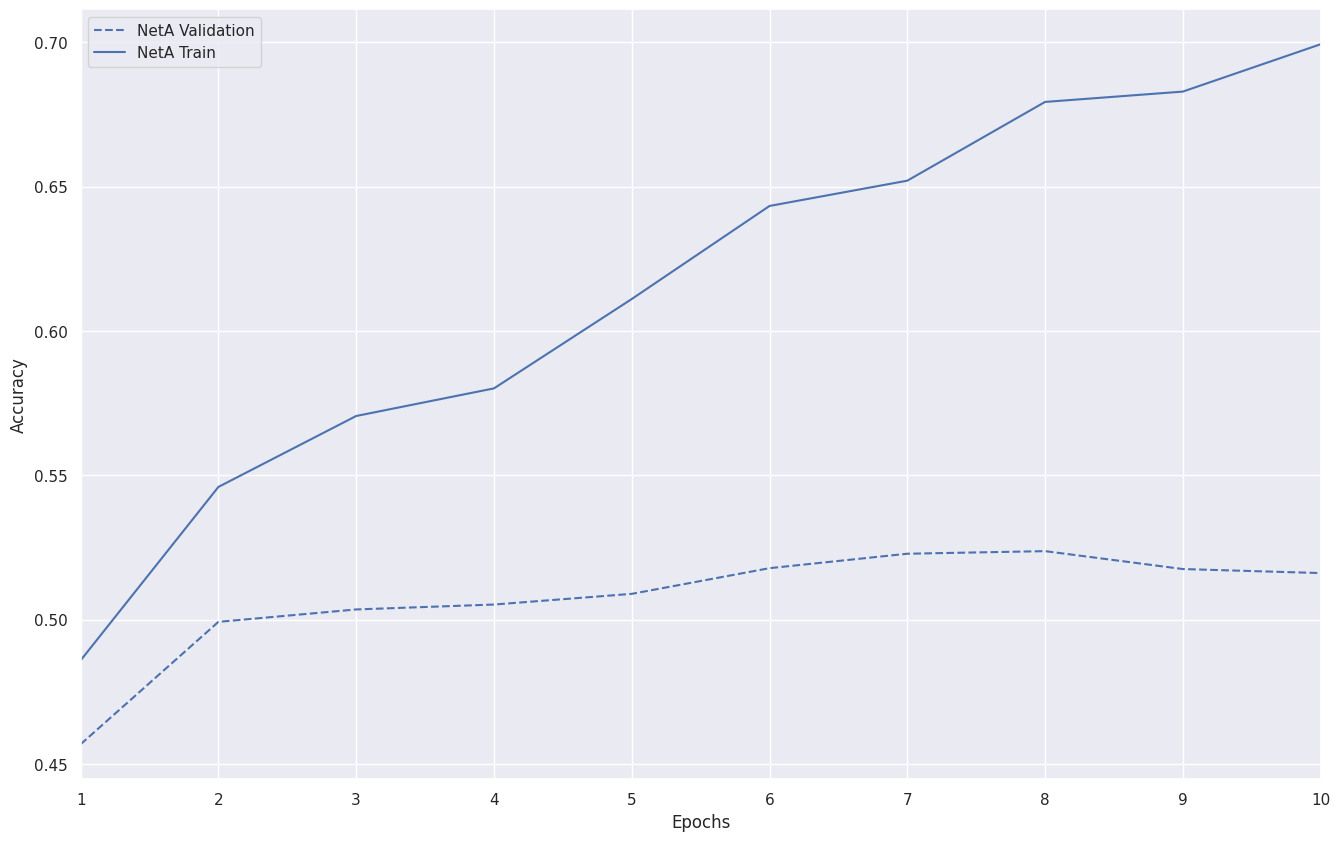

In [89]:
histories_A = []

netA = NetA()
print(f'==== Training NetA ====')
netA.to(device)
train_history_A, val_history_A, _ = train(netA, train_loader, val_loader,
    num_epochs=10, learning_rate=1e-3, compute_accs=True)
histories_A.append({
      'name': 'NetA',
      'train_accs': train_history_A,
      'val_accs': val_history_A
})
plot_history(histories_A)

## Model B:

==== Training NetB ====
Epoch [1/10], Step [100/500], Loss: 1.8605
Epoch [1/10], Step [200/500], Loss: 1.6270
Epoch [1/10], Step [300/500], Loss: 1.6380
Epoch [1/10], Step [400/500], Loss: 1.4934
Epoch [1/10], Step [500/500], Loss: 1.4239
Epoch [1/10], Train Accuracy 47.47%, Validation Accuracy 46.21%
Best Validation Accuracy 46.21%
Epoch [2/10], Step [100/500], Loss: 1.5901
Epoch [2/10], Step [200/500], Loss: 1.4287
Epoch [2/10], Step [300/500], Loss: 1.4815
Epoch [2/10], Step [400/500], Loss: 1.6264
Epoch [2/10], Step [500/500], Loss: 1.3128
Epoch [2/10], Train Accuracy 50.70%, Validation Accuracy 48.29%
Best Validation Accuracy 48.29%
Epoch [3/10], Step [100/500], Loss: 1.4099
Epoch [3/10], Step [200/500], Loss: 1.2900
Epoch [3/10], Step [300/500], Loss: 1.3666
Epoch [3/10], Step [400/500], Loss: 1.5059
Epoch [3/10], Step [500/500], Loss: 1.2207
Epoch [3/10], Train Accuracy 54.69%, Validation Accuracy 50.34%
Best Validation Accuracy 50.34%
Epoch [4/10], Step [100/500], Loss: 1.4276


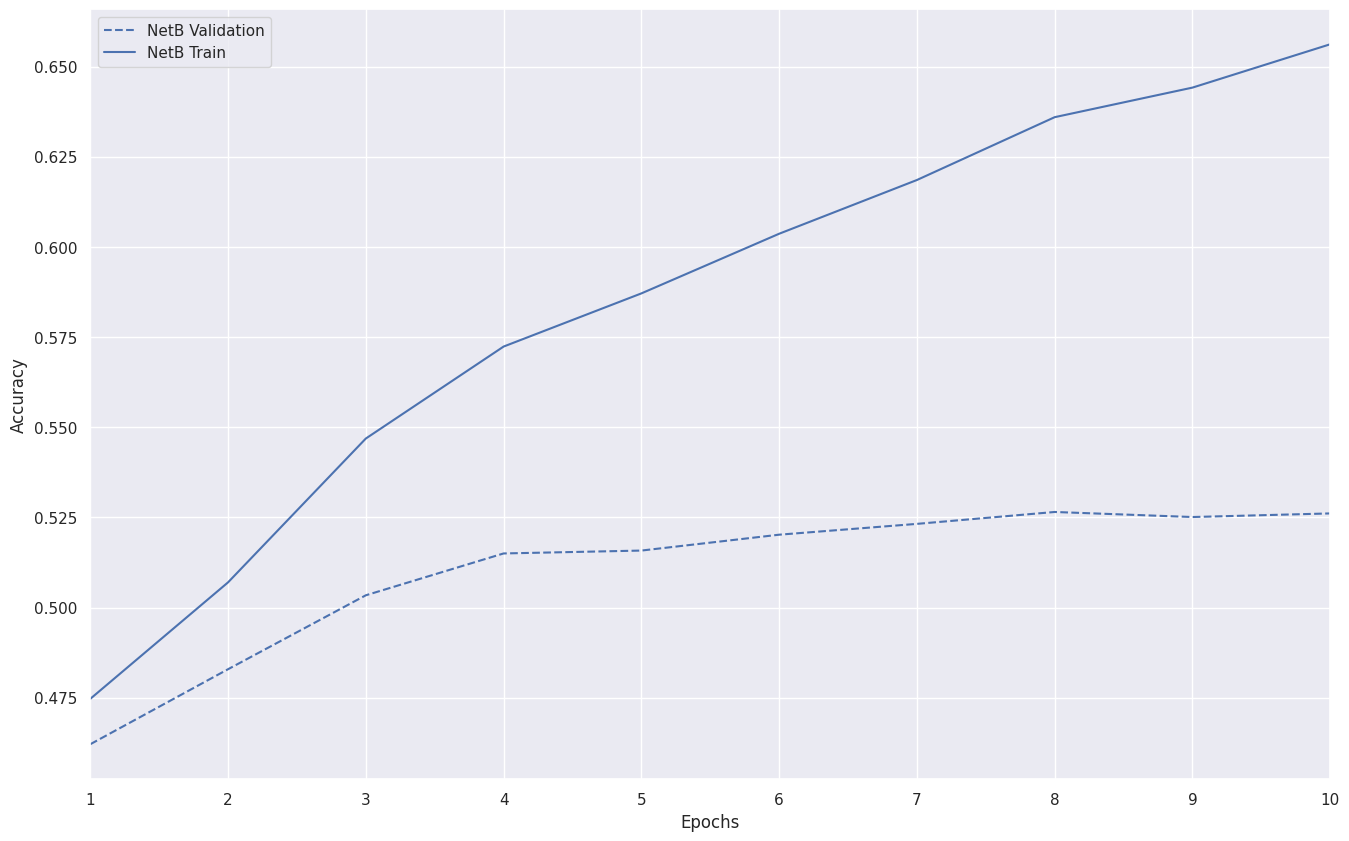

In [90]:
histories_B = []

netB = NetB()
print(f'==== Training NetB ====')
netB.to(device)
train_history_B, val_history_B, _ = train(netB, train_loader, val_loader,
        num_epochs=10, learning_rate=1e-3, compute_accs=True)
histories_B.append({
      'name': 'NetB',
      'train_accs': train_history_B,
      'val_accs': val_history_B
})
plot_history(histories_B)

## Model C:

==== Training NetC ====
Epoch [1/10], Step [100/500], Loss: 1.6351
Epoch [1/10], Step [200/500], Loss: 1.3933
Epoch [1/10], Step [300/500], Loss: 1.2397
Epoch [1/10], Step [400/500], Loss: 1.3772
Epoch [1/10], Step [500/500], Loss: 1.2248
Epoch [1/10], Train Accuracy 54.53%, Validation Accuracy 52.48%
Best Validation Accuracy 52.48%
Epoch [2/10], Step [100/500], Loss: 1.3418
Epoch [2/10], Step [200/500], Loss: 1.1269
Epoch [2/10], Step [300/500], Loss: 1.2342
Epoch [2/10], Step [400/500], Loss: 1.2088
Epoch [2/10], Step [500/500], Loss: 0.9463
Epoch [2/10], Train Accuracy 63.07%, Validation Accuracy 59.51%
Best Validation Accuracy 59.51%
Epoch [3/10], Step [100/500], Loss: 1.0233
Epoch [3/10], Step [200/500], Loss: 1.0562
Epoch [3/10], Step [300/500], Loss: 0.9885
Epoch [3/10], Step [400/500], Loss: 0.9926
Epoch [3/10], Step [500/500], Loss: 0.9378
Epoch [3/10], Train Accuracy 66.20%, Validation Accuracy 62.16%
Best Validation Accuracy 62.16%
Epoch [4/10], Step [100/500], Loss: 0.9730


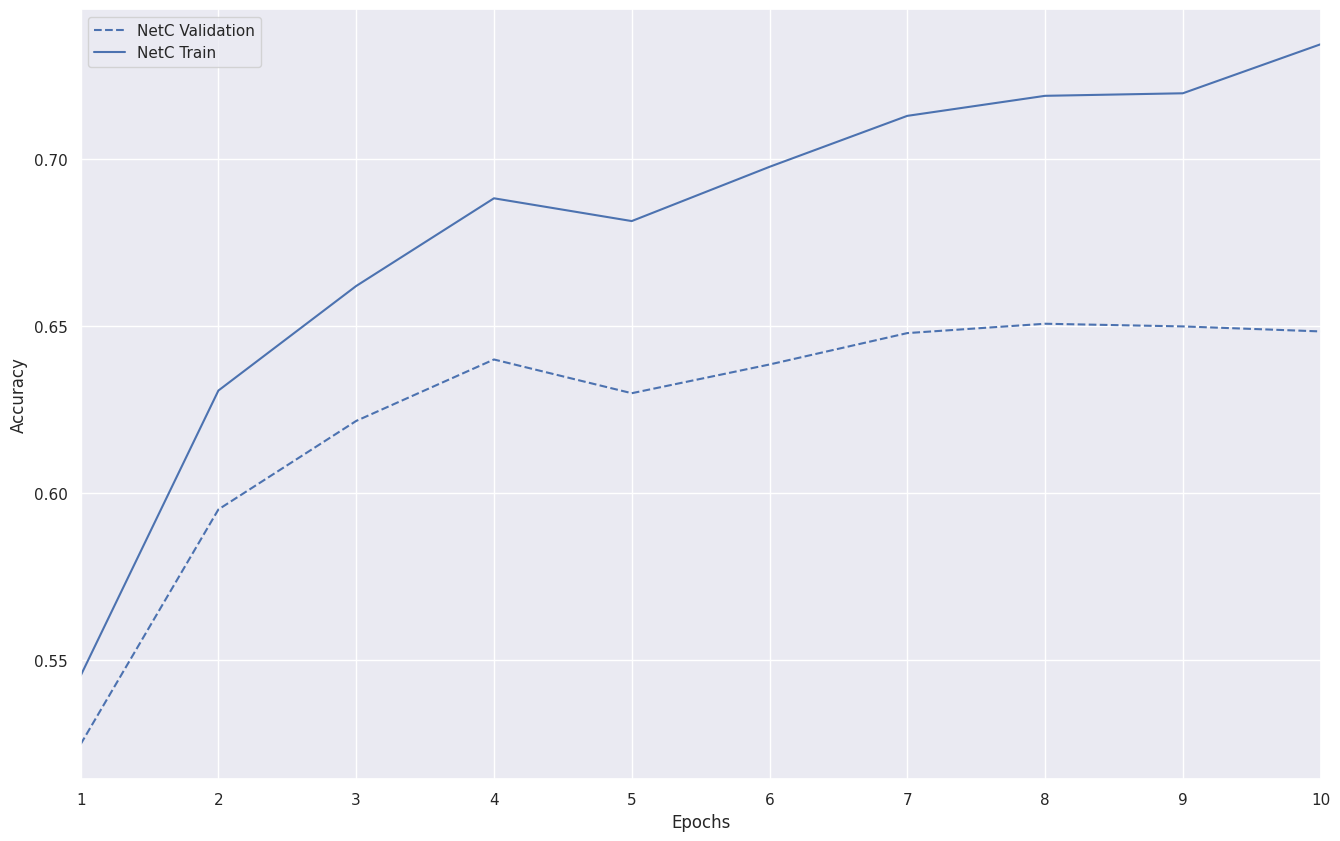

In [91]:
histories_C = []

netC = NetC()
print(f'==== Training NetC ====')
netC.to(device)
train_history_C, val_history_C, _ = train(netC, train_loader, val_loader,
        num_epochs=10, learning_rate=1e-3, compute_accs=True)
histories_C.append({
      'name': 'NetC',
      'train_accs': train_history_C,
      'val_accs': val_history_C
})
plot_history(histories_C)

## Model D:

==== Training NetD ====
Epoch [1/10], Step [100/500], Loss: 1.7122
Epoch [1/10], Step [200/500], Loss: 1.4721
Epoch [1/10], Step [300/500], Loss: 1.3198
Epoch [1/10], Step [400/500], Loss: 1.4017
Epoch [1/10], Step [500/500], Loss: 1.3029
Epoch [1/10], Train Accuracy 55.77%, Validation Accuracy 55.00%
Best Validation Accuracy 55.00%
Epoch [2/10], Step [100/500], Loss: 1.1872
Epoch [2/10], Step [200/500], Loss: 1.1025
Epoch [2/10], Step [300/500], Loss: 1.2137
Epoch [2/10], Step [400/500], Loss: 1.1280
Epoch [2/10], Step [500/500], Loss: 1.1995
Epoch [2/10], Train Accuracy 65.88%, Validation Accuracy 63.29%
Best Validation Accuracy 63.29%
Epoch [3/10], Step [100/500], Loss: 0.9487
Epoch [3/10], Step [200/500], Loss: 0.9721
Epoch [3/10], Step [300/500], Loss: 1.0083
Epoch [3/10], Step [400/500], Loss: 1.0590
Epoch [3/10], Step [500/500], Loss: 0.7335
Epoch [3/10], Train Accuracy 71.43%, Validation Accuracy 66.70%
Best Validation Accuracy 66.70%
Epoch [4/10], Step [100/500], Loss: 0.9512


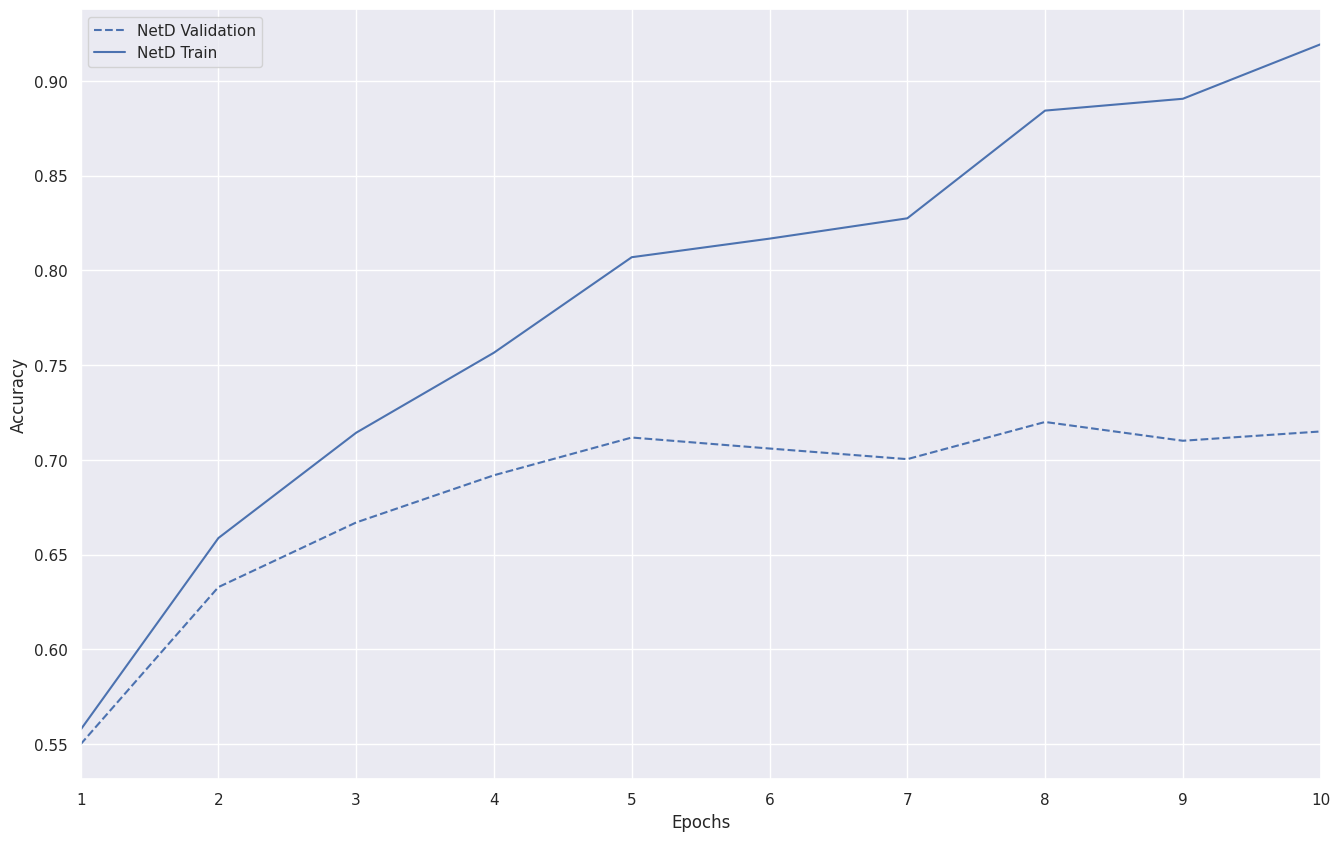

In [92]:
histories_D = []

netD = NetD()
print(f'==== Training NetD ====')
netD.to(device)
train_history_D, val_history_D, _ = train(netD, train_loader, val_loader,
        num_epochs=10, learning_rate=1e-3, compute_accs=True)
histories_D.append({
      'name': 'NetD',
      'train_accs': train_history_D,
      'val_accs': val_history_D
})
plot_history(histories_D)

## Model E:

==== Training NetE ====
Epoch [1/10], Step [100/500], Loss: 1.4803
Epoch [1/10], Step [200/500], Loss: 1.3464
Epoch [1/10], Step [300/500], Loss: 1.1403
Epoch [1/10], Step [400/500], Loss: 1.3307
Epoch [1/10], Step [500/500], Loss: 1.3040
Epoch [1/10], Train Accuracy 62.51%, Validation Accuracy 60.68%
Best Validation Accuracy 60.68%
Epoch [2/10], Step [100/500], Loss: 1.0576
Epoch [2/10], Step [200/500], Loss: 0.8042
Epoch [2/10], Step [300/500], Loss: 0.9383
Epoch [2/10], Step [400/500], Loss: 0.9330
Epoch [2/10], Step [500/500], Loss: 1.0918
Epoch [2/10], Train Accuracy 69.59%, Validation Accuracy 65.78%
Best Validation Accuracy 65.78%
Epoch [3/10], Step [100/500], Loss: 0.7519
Epoch [3/10], Step [200/500], Loss: 0.7812
Epoch [3/10], Step [300/500], Loss: 0.8684
Epoch [3/10], Step [400/500], Loss: 0.6518
Epoch [3/10], Step [500/500], Loss: 0.8587
Epoch [3/10], Train Accuracy 75.18%, Validation Accuracy 69.04%
Best Validation Accuracy 69.04%
Epoch [4/10], Step [100/500], Loss: 0.8391


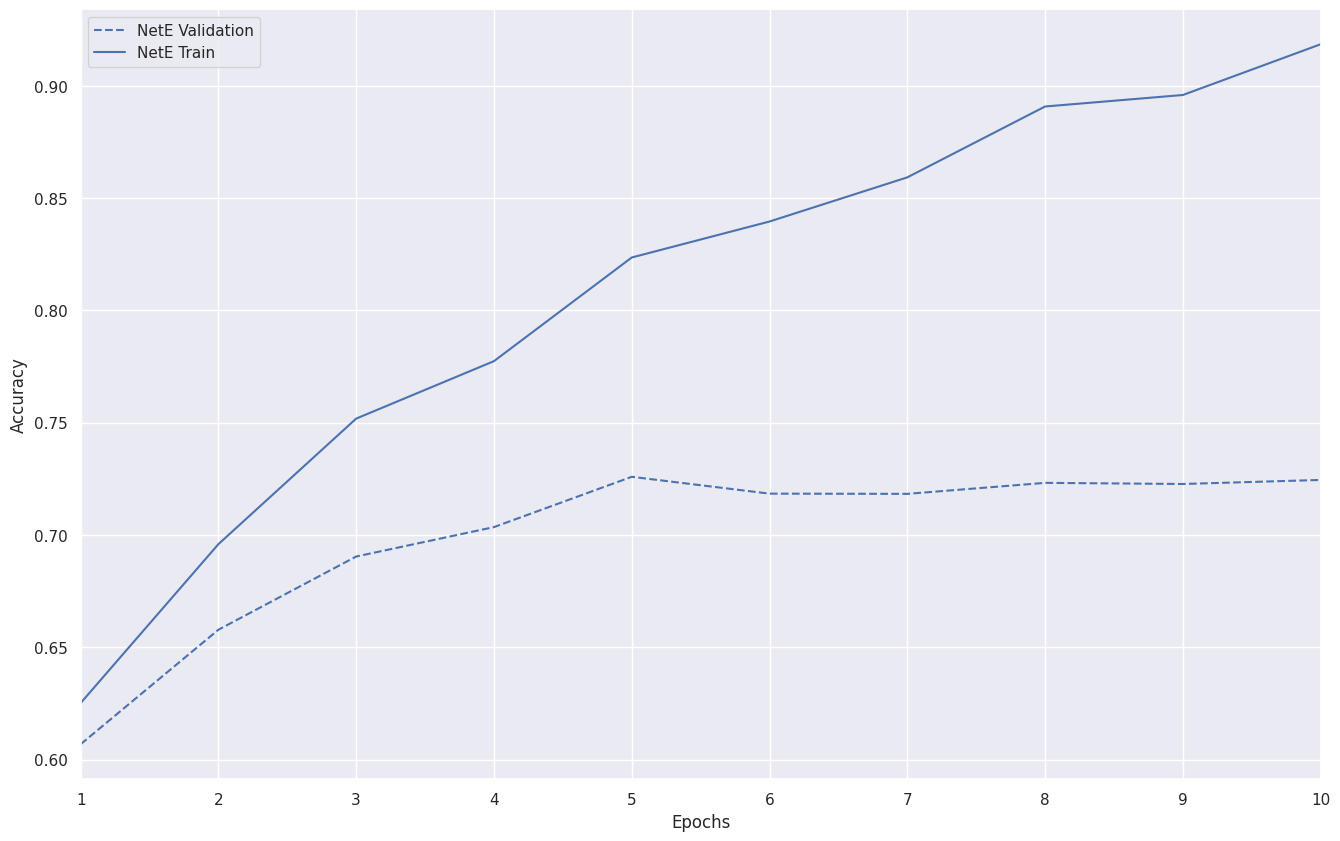

In [76]:
 histories_E = []

 netE = NetE()
 print(f'==== Training NetE ====')
 netE.to(device)
 train_history_E, val_history_E, _ = train(netE, train_loader, val_loader,
       num_epochs=10, learning_rate=1e-3, compute_accs=True)
 histories_E.append({
       'name': 'NetE',
       'train_accs': train_history_E,
       'val_accs': val_history_E
 })
 plot_history(histories_E)

# Model Performance Comparison

This section compares the training and validation performance of all implemented architectures on the CIFAR-10 dataset.

The results illustrate how increasing model complexity and introducing convolutional layers affect classification accuracy.

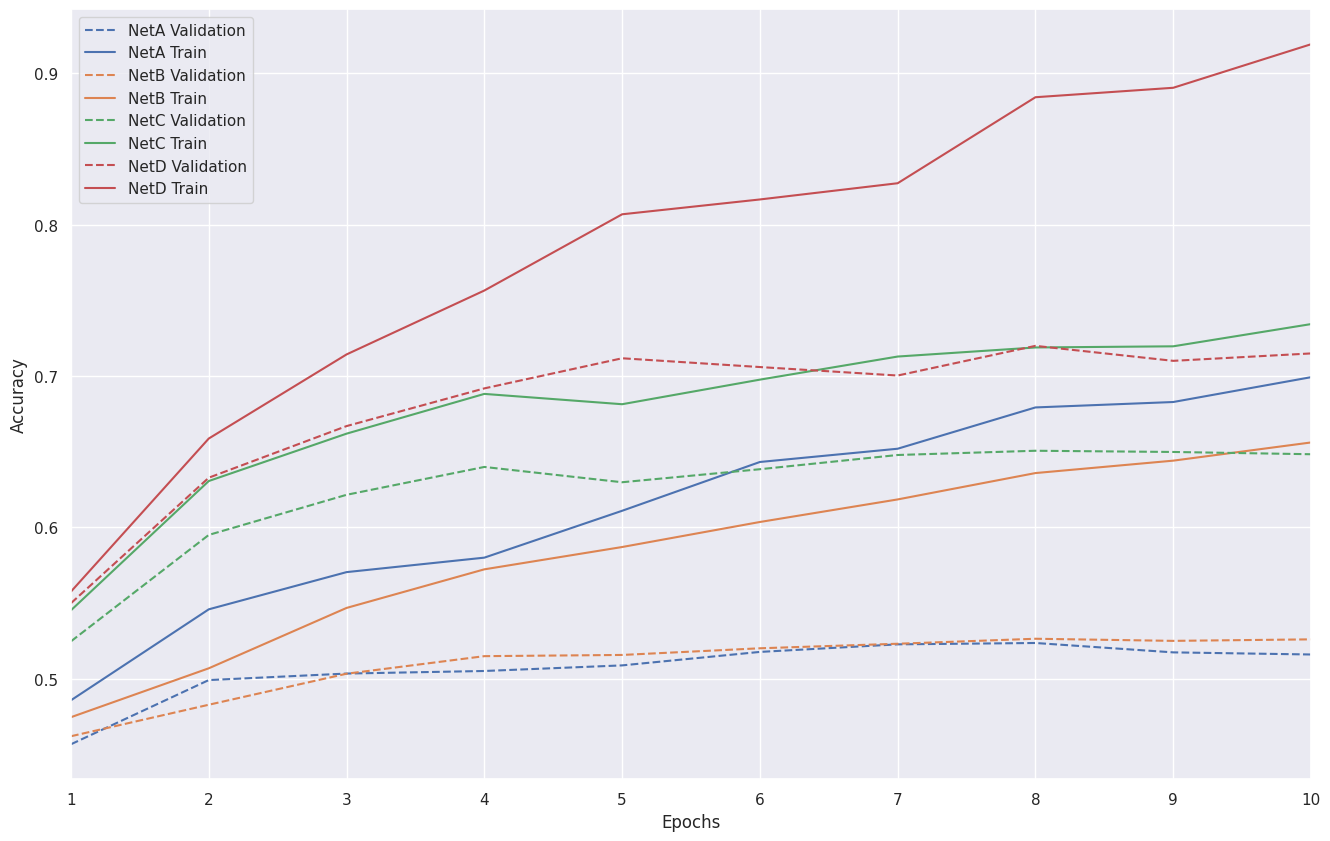

In [93]:
all_histories = histories_A + histories_B + histories_C + histories_D
plot_history(all_histories)

## Results Analysis

Key observations:

- Model A achieved the lowest validation accuracy, indicating that shallow fully connected networks struggle to learn complex image features.

- Model B improved performance through additional network depth, demonstrating the benefit of deeper feature representations.

- Model C significantly outperformed both fully connected architectures after introducing convolutional layers, highlighting the importance of spatial feature extraction in image classification.

- Model D achieved strong performance by increasing CNN depth and feature extraction capacity, reaching approximately 72% validation accuracy.

- Model E achieved the highest validation accuracy (72.59%) by incorporating Batch Normalization and Dropout. These regularization techniques improved model generalization and helped reduce overfitting.

Overall, convolutional neural networks consistently outperformed fully connected networks on the CIFAR-10 image classification task. Furthermore, the addition of regularization techniques provided a modest but measurable improvement in validation performance.

# Conclusion

This project compared multiple deep learning architectures for CIFAR-10 image classification using PyTorch.

The results showed that convolutional neural networks significantly outperform fully connected networks on image classification tasks. The best-performing model, which incorporated Batch Normalization and Dropout, achieved a validation accuracy of 72.59%.

These experiments highlight the importance of architecture design and regularization techniques in deep learning performance.